# Applied Exercise 10 - Survival analysis using Kaplan Meyer curves

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

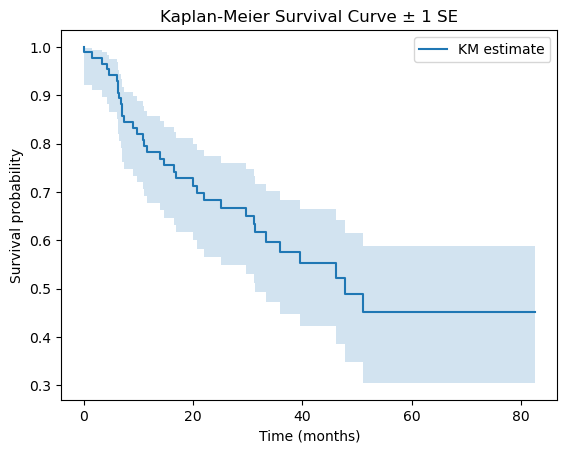

In [4]:
BrainCancer = load_data("BrainCancer")

kmf = KaplanMeierFitter()
kmf.fit(BrainCancer["time"], event_observed=BrainCancer["status"])

se = kmf.confidence_interval_survival_function_
surv = kmf.survival_function_

plt.step(surv.index, surv.iloc[:,0], where="post", label="KM estimate")
plt.fill_between(surv.index, surv.iloc[:,0] - (surv.iloc[:,0] - se.iloc[:,0]), surv.iloc[:,0] + (se.iloc[:,1] - surv.iloc[:,0]), step="post", alpha=0.2)
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier Survival Curve ± 1 SE")
plt.legend()
plt.show()

- Kaplan–Meier curve: an estimate of the probability of surviving beyond each time point; the curve starts at 1 (100%) and drops whenever a death/event occurs, while censored observations do not cause a drop. A higher curve means better survival. For example, S(24)=0.70 means an estimated 70% of patients survive beyond 24 months.
- From the above, it shows that the patients survival probablity decreases over time and reaches stagnation at approx. 45% of patients surviving 80+ months.

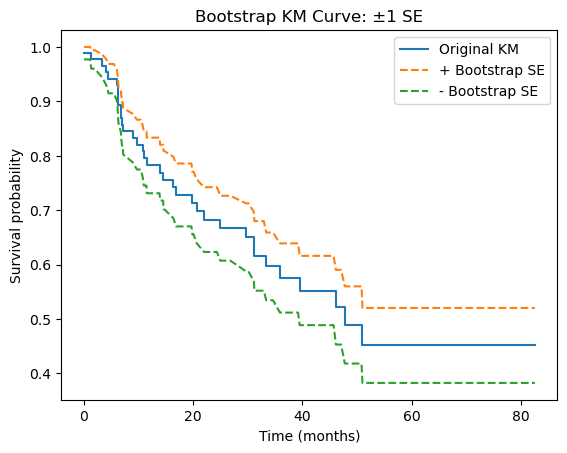

In [5]:
B = 200
n = len(BrainCancer)
times = np.sort(BrainCancer["time"].unique())
boot_surv = np.zeros((B, len(times)))

for b in range(B):
    idx = np.random.choice(n, n, replace=True)
    km = KaplanMeierFitter()
    km.fit(BrainCancer["time"].iloc[idx], event_observed=BrainCancer["status"].iloc[idx])
    boot_surv[b] = km.survival_function_at_times(times).values

boot_se = boot_surv.std(axis=0)

plt.step(times, kmf.survival_function_at_times(times).values, where="post", label="Original KM")
plt.plot(times, kmf.survival_function_at_times(times).values + boot_se, "--", label="+ Bootstrap SE")
plt.plot(times, kmf.survival_function_at_times(times).values - boot_se, "--", label="- Bootstrap SE")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.title("Bootstrap KM Curve: ±1 SE")
plt.legend()
plt.show()

The bootstrap SE measures how much the estimated survival curve varies across repeated samples. It is broadly similar to the standard errors from the original cruve.

In [6]:
X = pd.get_dummies(BrainCancer.drop(columns=["time","status"]), drop_first=True, dtype=float)
cox_data = pd.concat([BrainCancer[["time","status","ki","gtv"]], X.drop(columns=["ki","gtv"], errors="ignore")], axis=1)

cox = CoxPHFitter()
cox.fit(cox_data, duration_col="time", event_col="status")
print("=" * 60)
print("COX PROPORTIONAL HAZARDS MODEL")
print("=" * 60)
print(cox.summary[["coef","exp(coef)","p"]].to_string())

COX PROPORTIONAL HAZARDS MODEL
                          coef  exp(coef)         p
covariate                                          
ki                   -0.057920   0.943725  0.001563
gtv                   0.036041   1.036699  0.111125
sex_Male              0.097854   1.102802  0.786169
diagnosis_LG glioma  -1.091266   0.335791  0.057256
diagnosis_Meningioma -2.082012   0.124679  0.000004
diagnosis_Other      -1.235849   0.290588  0.048311
loc_Supratentorial    0.375835   1.456207  0.590156
stereo_SRT            0.139636   1.149855  0.815379


- The Cox model identifies which patient and tumor characteristics are associated with the hazard of death while adjusting for all other predictors.
- HR / exp(coef) > 1 indicates higher hazard and lower survival probability.
- From the above, ki (performance status indicator), diagnosis_Meningioma and diagnosis_Other have p values < 0.05 and diagnosis_LG glioma close to 0.05 while others have very large values signifying non association with the hazard of death.
- KI HR = 0.944 means that for each 1-point increase in KI, the estimated hazard of death is multiplied by 0.944, or decreases by about 5.6%, holding the other predictors constant.

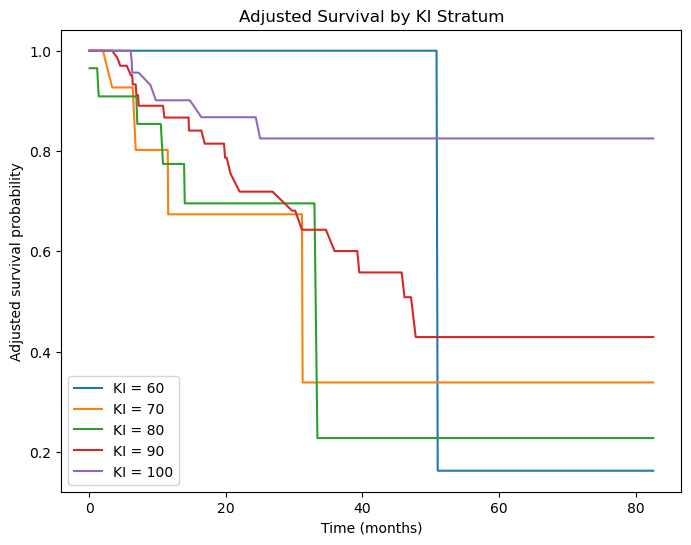

In [7]:
data = BrainCancer.copy()
data["ki_strata"] = data["ki"].replace({40: 60}).astype(str)

X = pd.get_dummies(data.drop(columns=["time","status","ki","ki_strata"]), drop_first=True, dtype=float)
cox_data = pd.concat([data[["time","status","ki_strata"]], X], axis=1)

cox_strat = CoxPHFitter()
cox_strat.fit(cox_data, duration_col="time", event_col="status", strata=["ki_strata"])

# Adjusted survival curves at mean/reference covariates
new_data = pd.DataFrame({c: [cox_data[c].mean()] for c in X.columns})
new_data = pd.concat([new_data] * 5, ignore_index=True)
new_data["ki_strata"] = ["60", "70", "80", "90", "100"]

surv = cox_strat.predict_survival_function(new_data)

plt.figure(figsize=(8,6))
for i, col in enumerate(surv.columns):
    plt.plot(surv.index, surv[col], label=f"KI = {new_data.loc[i,'ki_strata']}")
plt.xlabel("Time (months)")
plt.ylabel("Adjusted survival probability")
plt.title("Adjusted Survival by ki Stratum")
plt.legend()
plt.show()

- The adjusted curves compare survival across KI strata while controlling for the other predictors. A curve that lies higher indicates better adjusted survival, while a lower curve indicates higher adjusted mortality risk.
- From the above, ki can be concluded to be associated with survival. The original study also found KI to be associated with survival in univariate analysis.

# Applied Exercise 11 - Kaplan Meyer curves on a simulated dataset

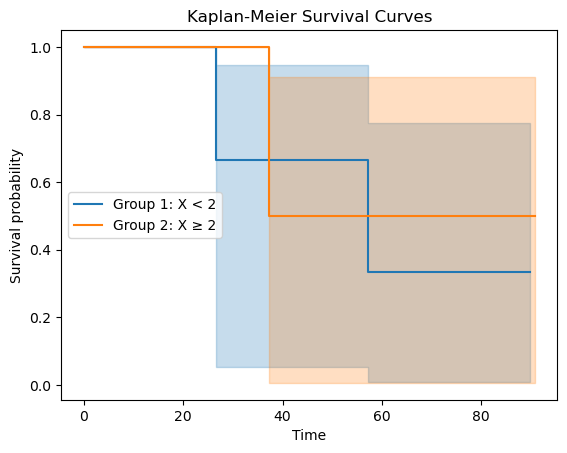

In [9]:
df = pd.DataFrame({"Y":[26.5,37.2,57.3,90.8,20.2,89.8],"delta":[1,1,1,0,0,0],"X":[0.1,11,-0.3,2.8,1.8,0.4]})
df["group"] = (df["X"] >= 2).astype(int)

km1 = KaplanMeierFitter()
km2 = KaplanMeierFitter()

g1 = df["group"] == 0
g2 = df["group"] == 1

km1.fit(df.loc[g1,"Y"], df.loc[g1,"delta"], label="Group 1: X < 2")
km2.fit(df.loc[g2,"Y"], df.loc[g2,"delta"], label="Group 2: X ≥ 2")

ax = km1.plot_survival_function()
km2.plot_survival_function(ax=ax)
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier Survival Curves")
plt.show()

In [10]:
cox = CoxPHFitter()
cox.fit(df[["Y","delta","group"]], duration_col="Y", event_col="delta")

print("=" * 60)
print("COX PROPORTIONAL HAZARDS MODEL")
print("=" * 60)
print(cox.summary[["coef","exp(coef)","se(coef)","p"]])

COX PROPORTIONAL HAZARDS MODEL
               coef  exp(coef)  se(coef)         p
covariate                                         
group     -0.340143   0.711668  1.235876  0.783144


- The two survival curves doesnt appear to be significantly different from each other.
- The model suggests "group" predictor is not statitically significant (p = 0.78 > 0.05).

In [11]:
result = logrank_test(df.loc[g1,"Y"], df.loc[g2,"Y"], event_observed_A=df.loc[g1,"delta"], event_observed_B=df.loc[g2,"delta"])

print("=" * 60)
print("LOG-RANK TEST")
print("=" * 60)
print(f"Test statistic: {result.test_statistic:.6f}")
print(f"p-value:        {result.p_value:.6f}")

LOG-RANK TEST
Test statistic: 0.076443
p-value:        0.782177


The log-rank test gives p = 0.782, essentially identical to the Cox score-test p-value, as expected for a single binary covariate.